## Exploratory data analysis and inspection of the WikiText dataset.

In [2]:
from datasets import load_dataset
import numpy as np
import matplotlib.pyplot as plt

In [3]:
dataset = load_dataset("wikitext", "wikitext-2-raw-v1")

print(dataset)

DatasetDict({
    test: Dataset({
        features: ['text'],
        num_rows: 4358
    })
    train: Dataset({
        features: ['text'],
        num_rows: 36718
    })
    validation: Dataset({
        features: ['text'],
        num_rows: 3760
    })
})


In [ ]:
## Analyze text lengths to determine appropriate max sequence length for training.
def clean_dataset(split):
    return [x["text"] for x in split if x["text"] is not None and len(x["text"].strip()) > 10]

train_clean = clean_dataset(dataset["train"])
val_clean = clean_dataset(dataset["validation"])
test_clean = clean_dataset(dataset["test"])

print("After Cleaning:")
print("Train:", len(train_clean))
print("Validation:", len(val_clean))
print("Test:", len(test_clean))

After Cleaning:
Train: 23547
Validation: 2454
Test: 2850


In [5]:
train_lengths = [len(text.split()) for text in train_clean]

print("Train Statistics:")
print("Mean length:", np.mean(train_lengths))
print("Median length:", np.median(train_lengths))
print("Min length:", np.min(train_lengths))
print("Max length:", np.max(train_lengths))

Train Statistics:
Mean length: 87.12307300293031
Median length: 76.0
Min length: 1
Max length: 699


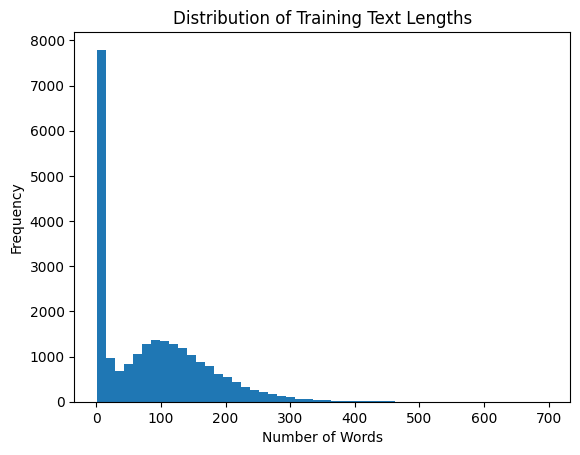

In [6]:
plt.hist(train_lengths, bins=50)
plt.title("Distribution of Training Text Lengths")
plt.xlabel("Number of Words")
plt.ylabel("Frequency")
plt.show()

In [ ]:

original_train = len(dataset["train"])
cleaned_train = len(train_clean)

removed_percentage = 100 * (original_train - cleaned_train) / original_train

print(f"Percentage of training data removed: {removed_percentage:.2f}%")

Percentage of training data removed: 35.87%
